In [2]:
#importing data

import pandas as pd
data = pd.read_csv("Global_Pollution_Analysis.csv")

In [25]:
#printing first 5 rows of data

print(data.head())

   Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index  \
0               272.70                 124.27                 51.95   
1                86.72                  60.34                117.22   
2                91.59                  83.36                121.72   
3               280.61                  67.16                 93.58   
4               179.16                 127.53                121.55   

   Industrial_Waste (in tons)  Energy_Recovered (in GWh)  \
0                    94802.83                     158.14   
1                    56283.92                     498.04   
2                    56256.02                     489.51   
3                    74864.73                     145.18   
4                    76862.06                      40.38   

   CO2_Emissions (in MT)  Renewable_Energy (%)  \
0                   5.30                 41.11   
1                   6.34                 36.44   
2                  49.69                  9.38   
3           

In [27]:
#checking for null values

print(data.isna().sum())

Air_Pollution_Index           0
Water_Pollution_Index         0
Soil_Pollution_Index          0
Industrial_Waste (in tons)    0
Energy_Recovered (in GWh)     0
                             ..
Year_2015                     0
Year_2016                     0
Year_2017                     0
Year_2018                     0
Year_2019                     0
Length: 204, dtype: int64


In [26]:
#checking for null values

print(data.isnull().sum())

Air_Pollution_Index           0
Water_Pollution_Index         0
Soil_Pollution_Index          0
Industrial_Waste (in tons)    0
Energy_Recovered (in GWh)     0
                             ..
Year_2015                     0
Year_2016                     0
Year_2017                     0
Year_2018                     0
Year_2019                     0
Length: 204, dtype: int64


In [28]:
#droping duplicates, if any

data.drop_duplicates(inplace=True)

In [7]:
print(data.columns)

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


In [8]:
#clean column names
data.columns = data.columns.str.strip()

#encode non-numeric columns

data = pd.get_dummies(data,columns=['Country','Year'],drop_first=True)

In [29]:
#sperataing data for in x and y ordinates 

x = data.drop("Energy_Recovered (in GWh)", axis=1)
y = data["Energy_Recovered (in GWh)"]

In [10]:
#feature scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_sc = scaler.fit_transform(x)

<Axes: xlabel='Energy_Recovered (in GWh)', ylabel='Count'>

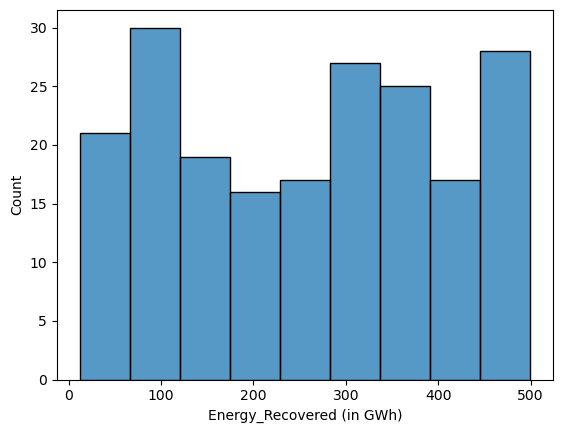

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data['Energy_Recovered (in GWh)'])

<Axes: >

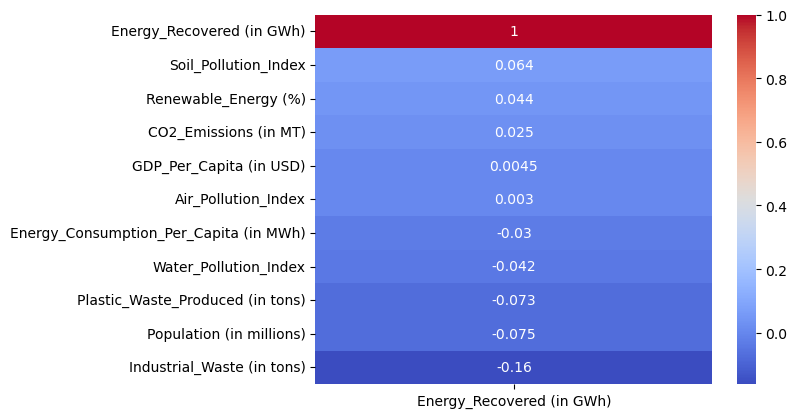

In [12]:
#correlation of Energy_Recovered with every other numeric column

num_data = data.loc[:,~data.columns.str.startswith(('Country_','Year_'))]

corr = num_data.corr()[['Energy_Recovered (in GWh)']].sort_values(by='Energy_Recovered (in GWh)',ascending=False)
sns.heatmap(corr,annot=True,cmap="coolwarm")

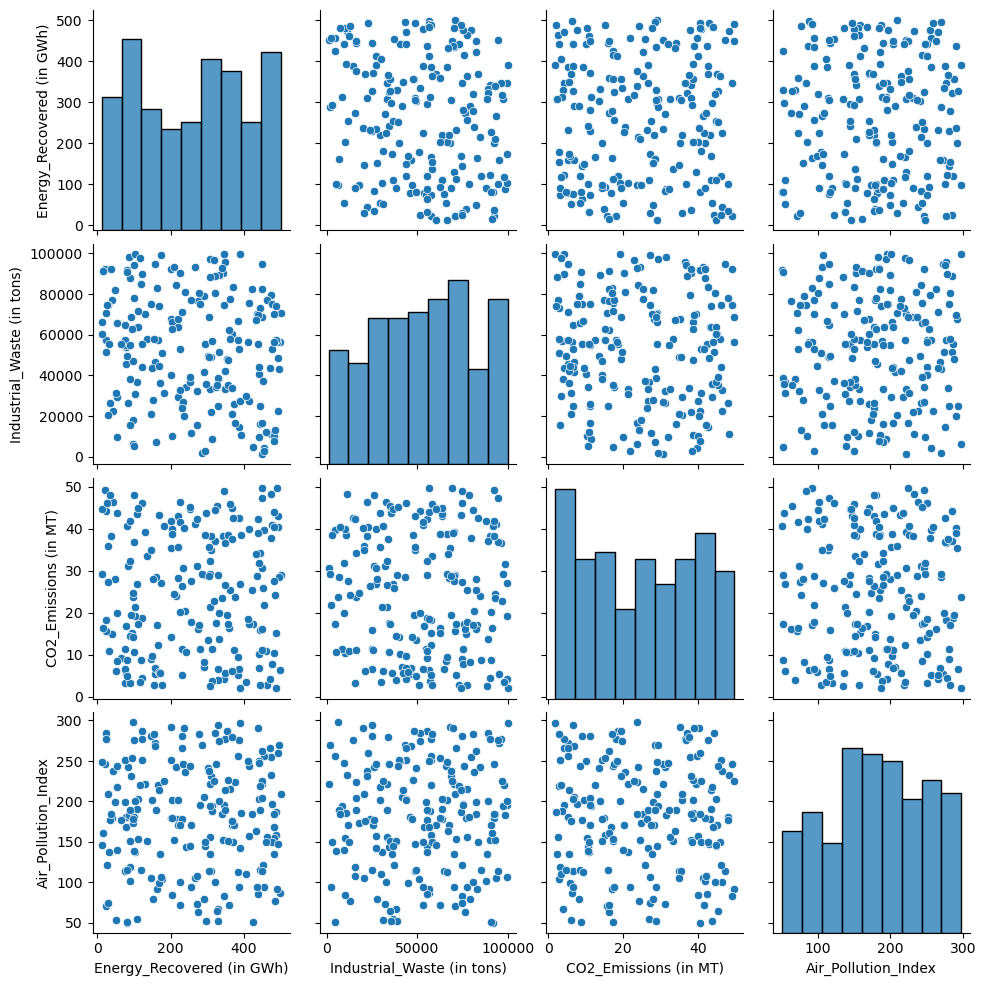

In [30]:
#pairplot to visualize relationships between key features and target variables
#help identify patterns,trends, and whether relationships are linear or randomn

sns.pairplot(num_data[['Energy_Recovered (in GWh)',
                       'Industrial_Waste (in tons)',
                       'CO2_Emissions (in MT)',
                       'Air_Pollution_Index']])

<Axes: ylabel='Industrial_Waste (in tons)'>

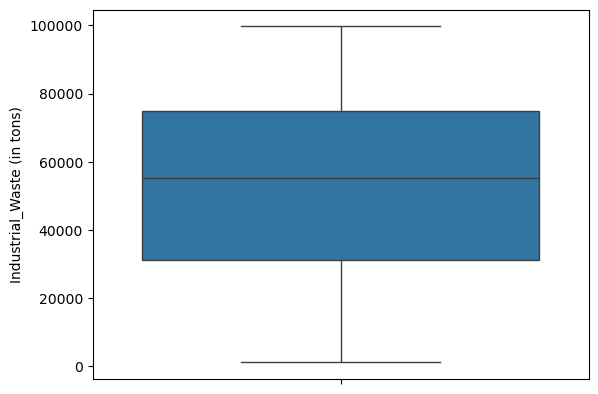

In [31]:
#boxplot to analyze distribution and detect outliers in industrial waste.
#show median, quartiles and spread of the data

sns.boxplot(data['Industrial_Waste (in tons)'])

In [15]:
top_features = corr[1:6].index
print(top_features)

Index(['Soil_Pollution_Index', 'Renewable_Energy (%)', 'CO2_Emissions (in MT)',
       'GDP_Per_Capita (in USD)', 'Air_Pollution_Index'],
      dtype='object')


In [16]:
#data selection

data2 = data[num_data.columns]
x = data2.drop('Energy_Recovered (in GWh)',axis =1)
y=data['Energy_Recovered (in GWh)']

In [32]:
#model creation

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

#spliting data for training and testing
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

#creating random tree regressor model
model= RandomForestRegressor()
model.fit(x_train,y_train)

#selecting important features from the all given features which effect the model more
importance = pd.Series(model.feature_importances_,index=x.columns)
top_features2 = importance.sort_values(ascending=False).head(5).index


In [18]:
print(top_features2)

Index(['Renewable_Energy (%)', 'Population (in millions)',
       'Water_Pollution_Index', 'Industrial_Waste (in tons)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')


In [19]:
x1 = data[top_features2]

In [33]:
x_train1,x_test1,y_train1,y_test1 = train_test_split(x1,y,test_size=0.2)

#traing data whit top 5 features
model= RandomForestRegressor()
model.fit(x_train1,y_train1)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
from sklearn.metrics import r2_score

#evalution of the model
pred = model.predict(x_test1)
print(r2_score(y_test,pred))

-0.0871909714133472


In [36]:
from sklearn.ensemble import GradientBoostingRegressor

#trying with gradient boosting regression because of the randomness of the data
model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(x_train1, y_train1)

pred = model.predict(x_test1)

from sklearn.metrics import r2_score
print(r2_score(y_test1, pred))

-0.33236129055345054


In [ ]:
#Final Insight:
#The main limitation of this project is data quality and feature relevance, not the modeling technique. 
#The results highlight that without strong underlying relationships, even advanced models cannot achieve high accuracy.


#Conclusion Statement:
#👉 Energy recovery in this dataset cannot be reliably predicted using the given features, 
#suggesting the need for more relevant or higher-quality data.